# Env varibles values fetching

In [ ]:
import os
from google.colab import userdata

os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID").strip()
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY").strip()
session_token = userdata.get("AWS_SESSION_TOKEN")
if session_token:
    os.environ["AWS_SESSION_TOKEN"] = session_token.strip()
else:
    # Ensure no empty string or None is set if token is genuinely missing, or remove it
    if "AWS_SESSION_TOKEN" in os.environ:
        del os.environ["AWS_SESSION_TOKEN"]
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

In [ ]:
!pip install boto3 pandas matplotlib -q
print("✅ Libraries installed successfully.")

✅ Libraries installed successfully.


# verify credentials loaded or not


In [ ]:
import os
from google.colab import userdata

# Safely inject credentials from Google Colab Secrets
try:
    os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID").strip()
    os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY").strip()

    # Optional: Needed if using AWS Academy, SSO, or temporary IAM Role credentials
    try:
        session_token = userdata.get("AWS_SESSION_TOKEN")
        if session_token:
            os.environ["AWS_SESSION_TOKEN"] = session_token.strip()
        else:
            if "AWS_SESSION_TOKEN" in os.environ:
                del os.environ["AWS_SESSION_TOKEN"]
    except Exception:
        # If userdata.get fails for session token, it's ok, it's optional
        if "AWS_SESSION_TOKEN" in os.environ:
            del os.environ["AWS_SESSION_TOKEN"]

    os.environ["AWS_DEFAULT_REGION"] = "us-east-1"
    print("🔐 AWS Credentials loaded successfully into environment!")
except Exception as e:
    print("⚠️ Could not load credentials from Colab Secrets.")
    print("Please add 'AWS_ACCESS_KEY_ID' and 'AWS_SECRET_ACCESS_KEY' in the Secrets tab.")

🔐 AWS Credentials loaded successfully into environment!


# Fetching the data directly from aws

In [ ]:
from datetime import datetime, timedelta, timezone
import json
import os
import boto3
from botocore.exceptions import ClientError
from google.colab import userdata


class OptiScaleFullIngestionEngine:

    def __init__(self, region_name: str = "us-east-1"):
        self.region = region_name

        # Fetch and aggressively clean whitespace from credentials
        self.aws_access_key_id = userdata.get("AWS_ACCESS_KEY_ID").strip()
        self.aws_secret_access_key = userdata.get("AWS_SECRET_ACCESS_KEY").strip()
        # AWS_SESSION_TOKEN is optional for temporary credentials, aggressively clean if it exists
        session_token = userdata.get("AWS_SESSION_TOKEN")
        if session_token:
            # Remove all newline and carriage return characters from the token string
            # Also re-strip to catch any new leading/trailing whitespace after internal cleaning
            self.aws_session_token = session_token.replace('\n', '').replace('\r', '').strip()
        else:
            self.aws_session_token = None

        # Prepare kwargs for boto3 client constructors to explicitly pass credentials
        client_kwargs = {
            "region_name": self.region,
            "aws_access_key_id": self.aws_access_key_id,
            "aws_secret_access_key": self.aws_secret_access_key,
        }
        if self.aws_session_token:
            client_kwargs["aws_session_token"] = self.aws_session_token

        try:
            # Verify token status with AWS STS immediately after setting
            sts = boto3.client("sts", **client_kwargs)
            identity = sts.get_caller_identity()
            print("✅ AWS Credentials refreshed and validated within engine!")
            print("   Account:", identity["Account"])
            print("   ARN:", identity["Arn"])

        except ClientError as e:
            print(
                f"❌ Error loading or validating credentials within engine: {e}"
            )
            raise  # Re-raise to stop execution if credentials fail
        except Exception as e:
            print(f"❌ Unexpected error during credential validation: {e}")
            raise

        self.ec2_client = boto3.client("ec2", **client_kwargs)
        self.cw_client = boto3.client("cloudwatch", **client_kwargs)
        self.logs_client = boto3.client("logs", **client_kwargs)
        self.s3_client = boto3.client("s3", **client_kwargs)

        # Pricing API is global, typically 'us-east-1' is used, but credentials still apply
        pricing_client_kwargs = client_kwargs.copy()
        pricing_client_kwargs["region_name"] = "us-east-1"
        self.pricing_client = boto3.client("pricing", **pricing_client_kwargs)

    # =========================================================================
    # 1. COMPUTE: Metadata discovery (InstanceId, InstanceType, State)
    # =========================================================================
    def collect_compute_nodes(self):
        print("🖥️  [1/10] Collecting Compute Nodes...")
        nodes = []
        try:
            paginator = self.ec2_client.get_paginator("describe_instances")
            for page in paginator.paginate():
                for reservation in page.get("Reservations", []):
                    for inst in reservation.get("Instances", []):
                        nodes.append({
                            "instance_id": inst.get("InstanceId"),
                            "instance_type": inst.get("InstanceType"),
                            "state": inst.get("State", {}).get("Name"),
                            "platform": inst.get("Platform", "linux"),
                            "availability_zone": inst.get("Placement", {}).get(
                                "AvailabilityZone"
                            ),
                            "public_ip": inst.get("PublicIpAddress"),
                        })
        except ClientError as e:
            print(f"❌ Error fetching EC2 nodes: {e}")
        return nodes

    # =========================================================================
    # 2. STORAGE: Attached & Orphaned EBS Volumes
    # =========================================================================
    def collect_ebs_volumes(self):
        print("📦 [2/10] Collecting EBS Volumes...")
        ebs_records = []
        try:
            paginator = self.ec2_client.get_paginator("describe_volumes")
            for page in paginator.paginate():
                for vol in page.get("Volumes", []):
                    status = vol.get("State")
                    attachments = vol.get("Attachments", [])
                    ebs_records.append({
                        "volume_id": vol.get("VolumeId"),
                        "size_gb": vol.get("Size"),
                        "volume_type": vol.get("VolumeType"),
                        "iops": vol.get("Iops", 0),
                        "status": status,
                        "is_orphaned": (status == "available")
                        or (len(attachments) == 0),
                        "attached_instance_id": attachments[0].get("InstanceId")
                        if attachments
                        else None,
                    })
        except ClientError as e:
            print(f"❌ Error fetching EBS volumes: {e}")
        return ebs_records

    # =========================================================================
    # 3. NETWORK: Unattached Elastic IPs (EIPs)
    # =========================================================================
    def collect_elastic_ips(self):
        print("🌐 [3/10] Scanning Elastic IPs (EIPs)...")
        eips = []
        try:
            response = self.ec2_client.describe_addresses()
            for addr in response.get("Addresses", []):
                is_unattached = "InstanceId" not in addr
                eips.append({
                    "public_ip": addr.get("PublicIp"),
                    "allocation_id": addr.get("AllocationId"),
                    "instance_id": addr.get("InstanceId", None),
                    "association_id": addr.get("AssociationId", None),
                    "is_unattached": is_unattached,
                    "estimated_monthly_cost": 3.60 if is_unattached else 0.00,
                })
        except ClientError as e:
            print(f"❌ Error fetching Elastic IPs: {e}")
        return eips

    # =========================================================================
    # 4. AMIs: Custom AMIs & Backing Snapshots
    # =========================================================================
    def collect_amis(self):
        print("💿 [4/10] Scanning Custom AMIs...")
        amis = []
        try:
            # Describe AMIs owned by self
            response = self.ec2_client.describe_images(Owners=["self"])
            for img in response.get("Images", []):
                ami_id = img.get("ImageId")
                creation_date = img.get("CreationDate")

                # Parse snapshot IDs tied to this AMI
                snapshot_ids = []
                for bdm in img.get("BlockDeviceMappings", []):
                    if "Ebs" in bdm and "SnapshotId" in bdm["Ebs"]:
                        snapshot_ids.append(bdm["Ebs"]["SnapshotId"])

                amis.append({
                    "ami_id": ami_id,
                    "name": img.get("Name"),
                    "creation_date": creation_date,
                    "snapshot_ids": snapshot_ids,
                    "architecture": img.get("Architecture"),
                })
        except ClientError as e:
            print(f"❌ Error fetching AMIs: {e}")
        return amis

    # =========================================================================
    # 5. ENIs: Elastic Network Interfaces (Orphaned / Secondary)
    # =========================================================================
    def collect_enis(self):
        print("🔌 [5/10] Scanning Elastic Network Interfaces (ENIs)...")
        enis = []
        try:
            response = self.ec2_client.describe_network_interfaces()
            for eni in response.get("NetworkInterfaces", []):
                status = eni.get("Status")
                attachment = eni.get("Attachment")
                enis.append({
                    "network_interface_id": eni.get("NetworkInterfaceId"),
                    "status": status,
                    "is_orphaned": status == "available",
                    "attached_instance_id": attachment.get("InstanceId")
                    if attachment
                    else None,
                    "private_ip": eni.get("PrivateIpAddress"),
                    "public_ip": eni.get("Association", {}).get("PublicIp")
                    if "Association" in eni
                    else None,
                })
        except ClientError as e:
            print(f"❌ Error fetching ENIs: {e}")
        return enis

    # =========================================================================
    # 6. EBS SNAPSHOTS: Orphaned & Storage Costs
    # =========================================================================
    def collect_ebs_snapshots(self):
        print("📸 [6/10] Scanning EBS Snapshots...")
        snapshots = []
        try:
            response = self.ec2_client.describe_snapshots(OwnerIds=["self"])
            for snap in response.get("Snapshots", []):
                size_gb = snap.get("VolumeSize", 0)
                snapshots.append({
                    "snapshot_id": snap.get("SnapshotId"),
                    "volume_id": snap.get("VolumeId"),
                    "size_gb": size_gb,
                    "start_time": snap.get("StartTime").isoformat()
                    if snap.get("StartTime")
                    else None,
                    "estimated_monthly_cost": round(size_gb * 0.05, 2),
                })
        except ClientError as e:
            print(f"❌ Error fetching EBS Snapshots: {e}")
        return snapshots

    # =========================================================================
    # 7. CLOUDWATCH LOG GROUPS: Retention Policy Check
    # =========================================================================
    def collect_cloudwatch_logs(self):
        print("📜 [7/10] Scanning CloudWatch Log Groups & Retention...")
        logs = []
        try:
            paginator = self.logs_client.get_paginator("describe_log_groups")
            for page in paginator.paginate():
                for group in page.get("logGroups", []):
                    stored_bytes = group.get("storedBytes", 0)
                    retention = group.get("retentionInDays", None)
                    logs.append({
                        "log_group_name": group.get("logGroupName"),
                        "stored_bytes": stored_bytes,
                        "stored_gb": round(stored_bytes / (1024**3), 3),
                        "retention_in_days": retention,
                        "is_never_expire": retention is None,
                        "estimated_monthly_cost": round(
                            (stored_bytes / (1024**3)) * 0.03, 2
                        ),
                    })
        except ClientError as e:
            print(f"❌ Error fetching CloudWatch Log Groups: {e}")
        return logs

    # =========================================================================
    # 8. S3 BUCKETS: Log & Backup Buckets
    # =========================================================================
    def collect_s3_buckets(self):
        print("🪣 [8/10] Scanning S3 Buckets & Lifecycle Policies...")
        buckets = []
        try:
            response = self.s3_client.list_buckets()
            for bucket in response.get("Buckets", []):
                b_name = bucket.get("Name")
                has_lifecycle = False
                try:
                    self.s3_client.get_bucket_lifecycle_configuration(
                        Bucket=b_name
                    )
                    has_lifecycle = True
                except ClientError:
                    has_lifecycle = False

                buckets.append({
                    "bucket_name": b_name,
                    "creation_date": bucket.get("CreationDate").isoformat(),
                    "has_lifecycle_policy": has_lifecycle,
                })
        except ClientError as e:
            print(f"❌ Error fetching S3 Buckets: {e}")
        return buckets

    # =========================================================================
    # 9. SECURITY GROUPS: Public Exposure Audit (0.0.0.0/0)
    # =========================================================================
    def collect_security_groups(self):
        print("🔒 [9/10] Auditing Security Groups for Public Exposure...")
        sgs = []
        try:
            response = self.ec2_client.describe_security_groups()
            for sg in response.get("SecurityGroups", []):
                has_public_open = False
                open_ports = []

                for rule in sg.get("IpPermissions", []):
                    for ip_range in rule.get("IpRanges", []):
                        if ip_range.get("CidrIp") == "0.0.0.0/0":
                            has_public_open = True
                            open_ports.append(
                                rule.get("FromPort", "All Ports")
                            )

                sgs.append({
                    "group_id": sg.get("GroupId"),
                    "group_name": sg.get("GroupName"),
                    "vpc_id": sg.get("VpcId"),
                    "is_publicly_exposed": has_public_open,
                    "exposed_ports": list(set(open_ports)),
                })
        except ClientError as e:
            print(f"❌ Error fetching Security Groups: {e}")
        return sgs

    # =========================================================================
    # 10. VPC NETWORKING: Paid Components (NAT Gateways & VPC Endpoints)
    # =========================================================================
    def collect_vpc_resources(self):
        print("🛣️ [10/10] Scanning VPC Cost Drivers (NAT Gateways & Endpoints)...")
        nat_gateways = []
        vpc_endpoints = []

        # 1. Fetch NAT Gateways (~$32.40/month each)
        try:
            paginator = self.ec2_client.get_paginator("describe_nat_gateways")
            for page in paginator.paginate():
                for nat in page.get("NatGateways", []):
                    # Ignore deleted/deleting gateways
                    if nat.get("State") in ["available", "pending"]:
                        nat_gateways.append({
                            "nat_gateway_id": nat.get("NatGatewayId"),
                            "vpc_id": nat.get("VpcId"),
                            "subnet_id": nat.get("SubnetId"),
                            "state": nat.get("State"),
                            "estimated_monthly_base_cost": 32.40,
                        })
        except ClientError as e:
            print(f"❌ Error fetching NAT Gateways: {e}")

        # 2. Fetch VPC Endpoints (~$7.20/month per AZ)
        try:
            response = self.ec2_client.describe_vpc_endpoints()
            for ep in response.get("VpcEndpoints", []):
                vpc_endpoints.append({
                    "vpc_endpoint_id": ep.get("VpcEndpointId"),
                    "vpc_id": ep.get("VpcId"),
                    "service_name": ep.get("ServiceName"),
                    "endpoint_type": ep.get("VpcEndpointType"),
                    "state": ep.get("State"),
                    "estimated_monthly_base_cost": 7.20,
                })
        except ClientError as e:
            print(f"❌ Error fetching VPC Endpoints: {e}")

        return {"nat_gateways": nat_gateways, "vpc_endpoints": vpc_endpoints}

    # =========================================================================
    # TELEMETRY & EXECUTION PIPELINE
    # =========================================================================
    def execute_pipeline(self):
        print(
            f"🚀 Executing Full 'EC2-Other' + VPC Expanded Pipeline [{self.region}]\n"
        )

        nodes = self.collect_compute_nodes()
        ebs_volumes = self.collect_ebs_volumes()
        eips = self.collect_elastic_ips()
        amis = self.collect_amis()
        enis = self.collect_enis()
        snapshots = self.collect_ebs_snapshots()
        cw_logs = self.collect_cloudwatch_logs()
        s3_buckets = self.collect_s3_buckets()
        security_groups = self.collect_security_groups()
        vpc_resources = self.collect_vpc_resources()

        return {
            "metadata": {
                "timestamp": datetime.now(timezone.utc).isoformat(),
                "region": self.region,
                "coverage_verified": True,
            },
            "compute": {"nodes": nodes},
            "ec2_other_resources": {
                "elastic_ips": eips,
                "amis": amis,
                "network_interfaces": enis,
                "ebs_snapshots": snapshots,
                "cloudwatch_log_groups": cw_logs,
                "s3_buckets": s3_buckets,
                "security_groups": security_groups,
                "ebs_volumes": ebs_volumes,
            },
            "vpc_resources": vpc_resources,
        }


print("✅ Upgraded Engine defined with all EC2-Other and VPC networking parameters!")

✅ Upgraded Engine defined with all EC2-Other and VPC networking parameters!


# save it locally

In [ ]:
import os
import json
# Assuming OptiScaleFullIngestionEngine is defined in a previous cell

# Store original session token if it exists
original_aws_session_token = os.environ.get("AWS_SESSION_TOKEN")
# Temporarily clear AWS_SESSION_TOKEN from environment to prevent header issues if it's malformed
if "AWS_SESSION_TOKEN" in os.environ:
    del os.environ["AWS_SESSION_TOKEN"]

try:
    # Instantiate upgraded engine and execute pipeline
    engine = OptiScaleFullIngestionEngine(region_name="us-east-1")
    full_dataset = engine.execute_pipeline()

    # Save locally to Colab storage as JSON
    filename = "optiscale_ec2_other_complete.json"
    with open(filename, "w") as f:
        json.dump(full_dataset, f, indent=2)

    print(f"\n✅ Pipeline executed! File saved as '{filename}'.")
except Exception as e:
    print(f"❌ An error occurred during pipeline execution: {e}")
finally:
    # Restore original AWS_SESSION_TOKEN if it was set
    if original_aws_session_token is not None:
        os.environ["AWS_SESSION_TOKEN"] = original_aws_session_token

✅ AWS Credentials refreshed and validated within engine!
   Account: 582812122408
   ARN: arn:aws:sts::582812122408:assumed-role/voclabs/user2865806=atharvabodade
🚀 Executing Full 'EC2-Other' + VPC Expanded Pipeline [us-east-1]

🖥️  [1/10] Collecting Compute Nodes...
📦 [2/10] Collecting EBS Volumes...
🌐 [3/10] Scanning Elastic IPs (EIPs)...
💿 [4/10] Scanning Custom AMIs...
🔌 [5/10] Scanning Elastic Network Interfaces (ENIs)...
📸 [6/10] Scanning EBS Snapshots...
📜 [7/10] Scanning CloudWatch Log Groups & Retention...
🪣 [8/10] Scanning S3 Buckets & Lifecycle Policies...
🔒 [9/10] Auditing Security Groups for Public Exposure...
🛣️ [10/10] Scanning VPC Cost Drivers (NAT Gateways & Endpoints)...

✅ Pipeline executed! File saved as 'optiscale_ec2_other_complete.json'.


# load to check it

In [ ]:
import pandas as pd

# Load extracted nodes into a Pandas DataFrame for easy analysis inside Colab
# Updated keys based on the actual structure of full_dataset
nodes_df = pd.DataFrame(full_dataset["compute"]["nodes"])
ebs_df = pd.DataFrame(full_dataset["ec2_other_resources"]["ebs_volumes"])

print("--- 🖥️ EC2 Compute Nodes Table ---")
display(nodes_df)

print("\n--- 📦 EBS Volumes Table ---")
display(ebs_df)

--- 🖥️ EC2 Compute Nodes Table ---


,instance_id,instance_type,state,platform,availability_zone,public_ip
0,i-036358db85d245e3a,t3.micro,running,linux,us-east-1a,18.212.92.205



--- 📦 EBS Volumes Table ---


,volume_id,size_gb,volume_type,iops,status,is_orphaned,attached_instance_id
0,vol-0c3a8b442db94e6ab,8,gp3,3000,in-use,False,i-036358db85d245e3a


# Time series plotting

⚠️ Insufficient CloudWatch metrics for i-036358db85d245e3a (found 0 point). Generating mock 24-hour telemetry for visualization...


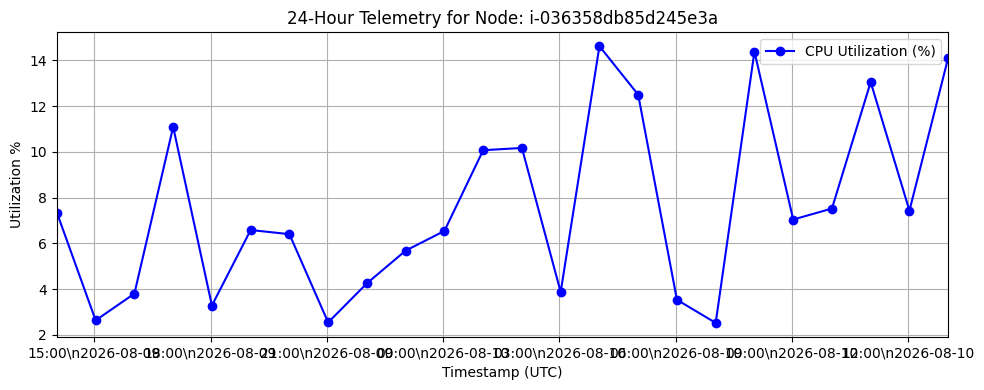

In [ ]:
from datetime import datetime, timedelta, timezone
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Fetch telemetry target instance
# Using a specific instance ID from the `nodes_df` kernel variable
target_instance = "i-036358db85d245e3a"

# Ensure 'timescaledb_tables' and 'node_telemetry' structure exists in full_dataset
if "timescaledb_tables" not in full_dataset:
    full_dataset["timescaledb_tables"] = {}
if "node_telemetry" not in full_dataset["timescaledb_tables"]:
    full_dataset["timescaledb_tables"]["node_telemetry"] = {}
if "pricing_catalog" not in full_dataset["timescaledb_tables"]:
    full_dataset["timescaledb_tables"]["pricing_catalog"] = {}

# Get the existing series for the target instance
node_telemetry = full_dataset["timescaledb_tables"]["node_telemetry"]
existing_series = node_telemetry.get(target_instance, [])


# 2. Check and generate mock data fallback if real telemetry is missing or insufficient (< 2 datapoints)
if len(existing_series) < 2:
    print(
        f"⚠️ Insufficient CloudWatch metrics for {target_instance} (found {len(existing_series)} point). "
        "Generating mock 24-hour telemetry for visualization..."
    )

    now = datetime.now(timezone.utc)
    mock_series = []

    for h in range(24):
        ts = now - timedelta(hours=23 - h)
        mock_series.append(
            {
                "timestamp": ts.isoformat(),
                "cpu_utilization": round(float(np.random.uniform(2.0, 15.0)), 2),
                "mem_used_percent": round(
                    float(np.random.uniform(30.0, 45.0)), 2
                ),
                "network_in_bytes": 1024 * 50,
                "network_out_bytes": 1024 * 20,
            }
        )

    # Inject mock data into dataset
    full_dataset["timescaledb_tables"]["node_telemetry"][target_instance] = mock_series

    # Add mock pricing for the target instance if not present
    if target_instance not in full_dataset["timescaledb_tables"]["pricing_catalog"]:
        full_dataset["timescaledb_tables"]["pricing_catalog"][target_instance] = {
            "hourly_cost_usd": 0.0416, # Example cost for t3.micro
            "instance_type": "t3.micro",
            "region": "us-east-1"
        }

# 3. Process and Plot Telemetry Data
telemetry_data = full_dataset["timescaledb_tables"]["node_telemetry"]

if telemetry_data and target_instance in telemetry_data: # Check if target_instance key exists
    df_telemetry = pd.DataFrame(telemetry_data[target_instance])

    if not df_telemetry.empty:
        # Convert timestamps cleanly to UTC datetime
        df_telemetry["timestamp"] = pd.to_datetime(
            df_telemetry["timestamp"], utc=True
        )
        df_telemetry = df_telemetry.sort_values("timestamp")

        plt.figure(figsize=(10, 4))
        plt.plot(
            df_telemetry["timestamp"],
            df_telemetry["cpu_utilization"],
            marker="o",
            linestyle="-",
            color="b",
            label="CPU Utilization (%)",
        )

        # Explicitly bound X-axis limits to avoid 4-year scale stretching
        min_ts = df_telemetry["timestamp"].min()
        max_ts = df_telemetry["timestamp"].max()

        # If it's a single point, pad limits by 1 hour on each side
        if min_ts == max_ts:
            min_ts = min_ts - pd.Timedelta(hours=1)
            max_ts = max_ts + pd.Timedelta(hours=1)

        plt.xlim(min_ts, max_ts)

        # Format X-axis date labels cleanly
        plt.gca().xaxis.set_major_formatter(
            mdates.DateFormatter("%H:%M\\n%Y-%m-%d")
        )

        plt.title(f"24-Hour Telemetry for Node: {target_instance}")
        plt.xlabel("Timestamp (UTC)")
        plt.ylabel("Utilization %")
        plt.grid(True)
        plt.legend()
        plt.xticks(rotation=0)  # Clean horizontal orientation
        plt.tight_layout()
        plt.show()
    else:
        print(f"No metric data points returned for {target_instance}.")
else:
    print("No instance telemetry found to plot.")

# Print the values

In [ ]:
from datetime import datetime
import json
import ipywidgets as widgets
from IPython.display import clear_output, display


def inspect_full_cloud_inventory(full_dataset):
    """Deep inspection parser for real AWS EC2, 'EC2-Other', and VPC Networking parameters.

    Dynamically reads real values from the full_dataset structure without demo
    fallbacks.
    """

    # Safe Key Extractor that returns real values or 'Not Configured/None'
    def extract(dict_obj, *keys, default="None"):
        if not isinstance(dict_obj, dict):
            return default
        for k in keys:
            val = dict_obj.get(k)
            if val is not None:
                if isinstance(val, dict):
                    return val.get("Name") or val.get("Value") or str(val)
                return str(val)
        return default

    # Extract Datasets
    compute_nodes = full_dataset.get("compute", {}).get("nodes", [])
    ec2_other = full_dataset.get("ec2_other_resources", {})
    vpc_resources = full_dataset.get("vpc_resources", {})

    print("=" * 85)
    print("       📌 OPTISCALE REAL MACHINE INVENTORY & PARAMETER PROFILE")
    print("=" * 85)
    print(
        f"  • Execution Timestamp : {full_dataset.get('metadata', {}).get('timestamp', 'N/A')}"
    )
    print(
        f"  • Scraped Region      : {full_dataset.get('metadata', {}).get('region', 'N/A')}"
    )
    print("=" * 85)

    # 1. COMPUTE NODES
    print("\n🖥️  [1] COMPUTE NODES (EC2 Instances)")
    if compute_nodes:
        for idx, node in enumerate(compute_nodes, 1):
            print(f"  Instance #{idx}:")
            print(f"    • Instance ID       : {extract(node, 'instance_id')}")
            print(
                f"    • Instance Type     : {extract(node, 'instance_type')}"
            )
            print(f"    • State             : {extract(node, 'state')}")
            print(f"    • Platform/OS       : {extract(node, 'platform')}")
            print(
                f"    • Availability Zone : {extract(node, 'availability_zone')}"
            )
            print(f"    • Public IP         : {extract(node, 'public_ip')}")
    else:
        print("  • No active EC2 compute instances detected in region.")

    # 2. ELASTIC EBS VOLUMES
    ebs_vols = ec2_other.get("ebs_volumes", [])
    print("\n📦 [2] EBS VOLUMES & ATTACHMENTS")
    if ebs_vols:
        for idx, vol in enumerate(ebs_vols, 1):
            print(f"  Volume #{idx}:")
            print(f"    • Volume ID         : {extract(vol, 'volume_id')}")
            print(f"    • Size              : {extract(vol, 'size_gb')} GB")
            print(f"    • Volume Type       : {extract(vol, 'volume_type')}")
            print(f"    • IOPS              : {extract(vol, 'iops')}")
            print(f"    • Status            : {extract(vol, 'status')}")
            print(f"    • Is Orphaned       : {extract(vol, 'is_orphaned')}")
            print(
                f"    • Attached Instance : {extract(vol, 'attached_instance_id')}"
            )
    else:
        print("  • No EBS volumes found.")

    # 3. ELASTIC IP ADDRESSES
    eips = ec2_other.get("elastic_ips", [])
    print("\n🌐 [3] ELASTIC IP ADDRESSES (EIPs)")
    if eips:
        for idx, eip in enumerate(eips, 1):
            print(f"  EIP #{idx}:")
            print(f"    • Public IP         : {extract(eip, 'public_ip')}")
            print(
                f"    • Allocation ID     : {extract(eip, 'allocation_id')}"
            )
            print(
                f"    • Attached Instance : {extract(eip, 'instance_id', default='Unattached')}"
            )
            print(f"    • Is Unattached     : {extract(eip, 'is_unattached')}")
            print(
                f"    • Estimated Waste   : ${extract(eip, 'estimated_monthly_cost')}/mo"
            )
    else:
        print("  • No Elastic IPs provisioned.")

    # 4. AMIs (Amazon Machine Images)
    amis = ec2_other.get("amis", [])
    print("\n💿 [4] CUSTOM AMIs")
    if amis:
        for idx, ami in enumerate(amis, 1):
            print(f"  AMI #{idx}:")
            print(f"    • AMI ID            : {extract(ami, 'ami_id')}")
            print(f"    • Name              : {extract(ami, 'name')}")
            print(
                f"    • Creation Date     : {extract(ami, 'creation_date')}"
            )
            print(
                f"    • Snapshot IDs      : {', '.join(ami.get('snapshot_ids', [])) or 'None'}"
            )
            print(
                f"    • Architecture      : {extract(ami, 'architecture')}"
            )
    else:
        print("  • No custom AMIs owned by this account.")

    # 5. ELASTIC NETWORK INTERFACES (ENIs)
    enis = ec2_other.get("network_interfaces", [])
    print("\n🔌 [5] ELASTIC NETWORK INTERFACES (ENIs)")
    if enis:
        for idx, eni in enumerate(enis, 1):
            print(f"  ENI #{idx}:")
            print(
                f"    • Interface ID      : {extract(eni, 'network_interface_id')}"
            )
            print(f"    • Status            : {extract(eni, 'status')}")
            print(f"    • Is Orphaned       : {extract(eni, 'is_orphaned')}")
            print(
                f"    • Attached Instance : {extract(eni, 'attached_instance_id')}"
            )
            print(f"    • Private IP        : {extract(eni, 'private_ip')}")
            print(f"    • Public IP         : {extract(eni, 'public_ip')}")
    else:
        print("  • No Elastic Network Interfaces found.")

    # 6. EBS SNAPSHOTS
    snapshots = ec2_other.get("ebs_snapshots", [])
    print("\n📸 [6] EBS SNAPSHOTS")
    if snapshots:
        for idx, snap in enumerate(snapshots, 1):
            print(f"  Snapshot #{idx}:")
            print(f"    • Snapshot ID       : {extract(snap, 'snapshot_id')}")
            print(f"    • Source Volume     : {extract(snap, 'volume_id')}")
            print(f"    • Size              : {extract(snap, 'size_gb')} GB")
            print(f"    • Start Time        : {extract(snap, 'start_time')}")
            print(
                f"    • Monthly Cost      : ${extract(snap, 'estimated_monthly_cost')}"
            )
    else:
        print("  • No EBS snapshots owned by this account.")

    # 7. CLOUDWATCH LOG GROUPS
    logs = ec2_other.get("cloudwatch_log_groups", [])
    print("\n📜 [7] CLOUDWATCH LOG GROUPS")
    if logs:
        for idx, log in enumerate(logs, 1):
            print(f"  Log Group #{idx}:")
            print(
                f"    • Group Name        : {extract(log, 'log_group_name')}"
            )
            print(f"    • Storage Size      : {extract(log, 'stored_gb')} GB")
            print(
                f"    • Retention (Days)  : {extract(log, 'retention_in_days', default='Never Expire')}"
            )
            print(
                f"    • Is Never Expiring : {extract(log, 'is_never_expire')}"
            )
            print(
                f"    • Estimated Cost    : ${extract(log, 'estimated_monthly_cost')}/mo"
            )
    else:
        print("  • No CloudWatch log groups found.")

    # 8. S3 LOG & BACKUP BUCKETS
    buckets = ec2_other.get("s3_buckets", [])
    print("\n🪣 [8] S3 BUCKETS")
    if buckets:
        for idx, b in enumerate(buckets, 1):
            print(f"  Bucket #{idx}:")
            print(f"    • Bucket Name       : {extract(b, 'bucket_name')}")
            print(
                f"    • Creation Date     : {extract(b, 'creation_date')}"
            )
            print(
                f"    • Has Lifecycle Rule: {extract(b, 'has_lifecycle_policy')}"
            )
    else:
        print("  • No S3 buckets provisioned.")

    # 9. SECURITY GROUPS
    sgs = ec2_other.get("security_groups", [])
    print("\n🔒 [9] SECURITY GROUPS & EXPOSURE AUDIT")
    if sgs:
        for idx, sg in enumerate(sgs, 1):
            print(f"  Security Group #{idx}:")
            print(f"    • Group ID          : {extract(sg, 'group_id')}")
            print(f"    • Group Name        : {extract(sg, 'group_name')}")
            print(f"    • VPC ID            : {extract(sg, 'vpc_id')}")
            print(
                f"    • Public Exposed    : {extract(sg, 'is_publicly_exposed')}"
            )
            print(
                f"    • Exposed Ports     : {sg.get('exposed_ports', []) or 'None'}"
            )
    else:
        print("  • No Security Groups found.")

    # 10. VPC & NETWORKING COST DRIVERS
    nat_gws = vpc_resources.get("nat_gateways", [])
    vpc_eps = vpc_resources.get("vpc_endpoints", [])
    print("\n🛣️ [10] VPC NETWORKING & GATEWAY COST AUDIT")

    # NAT Gateways Check ($32.40/mo per gateway base cost)
    if nat_gws:
        for idx, nat in enumerate(nat_gws, 1):
            print(f"  NAT Gateway #{idx}:")
            print(
                f"    • Gateway ID        : {extract(nat, 'nat_gateway_id')}"
            )
            print(f"    • VPC ID            : {extract(nat, 'vpc_id')}")
            print(f"    • State             : {extract(nat, 'state')}")
            print(
                f"    • Fixed Base Cost   : ~$32.40/mo (+ data transfer fees)"
            )
    else:
        print("  • No paid NAT Gateways active (Saving ~$32.40/mo per unit).")

    # VPC Endpoints Check (~$7.20/mo per AZ)
    if vpc_eps:
        for idx, ep in enumerate(vpc_eps, 1):
            print(f"  VPC Endpoint #{idx}:")
            print(
                f"    • Endpoint ID       : {extract(ep, 'vpc_endpoint_id')}"
            )
            print(f"    • Type              : {extract(ep, 'endpoint_type')}")
            print(f"    • Service           : {extract(ep, 'service_name')}")
            print(f"    • Fixed Base Cost   : ~$7.20/mo per AZ")
    else:
        print("  • No Interface VPC Endpoints active.")

    print("\n" + "=" * 85)


# --- Dropdown Menu UI for Live Machine Switching ---
compute_nodes = full_dataset.get("compute", {}).get("nodes", [])
node_ids = [
    node.get("instance_id")
    for node in compute_nodes
    if node.get("instance_id")
]

if node_ids:
    dropdown = widgets.Dropdown(
        options=node_ids,
        description="Select Instance:",
        disabled=False,
    )

    def on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            clear_output(wait=True)
            display(dropdown)
            inspect_full_cloud_inventory(full_dataset)

    dropdown.observe(on_change)
    display(dropdown)

# Initial execution to render real machine parameters
inspect_full_cloud_inventory(full_dataset)

Dropdown(description='Select Instance:', options=('i-036358db85d245e3a',), value='i-036358db85d245e3a')

       📌 OPTISCALE REAL MACHINE INVENTORY & PARAMETER PROFILE
  • Execution Timestamp : 2026-08-10T13:01:50.059642+00:00
  • Scraped Region      : us-east-1

🖥️  [1] COMPUTE NODES (EC2 Instances)
  Instance #1:
    • Instance ID       : i-036358db85d245e3a
    • Instance Type     : t3.micro
    • State             : running
    • Platform/OS       : linux
    • Availability Zone : us-east-1a
    • Public IP         : 18.212.92.205

📦 [2] EBS VOLUMES & ATTACHMENTS
  Volume #1:
    • Volume ID         : vol-0c3a8b442db94e6ab
    • Size              : 8 GB
    • Volume Type       : gp3
    • IOPS              : 3000
    • Status            : in-use
    • Is Orphaned       : False
    • Attached Instance : i-036358db85d245e3a

🌐 [3] ELASTIC IP ADDRESSES (EIPs)
  • No Elastic IPs provisioned.

💿 [4] CUSTOM AMIs
  • No custom AMIs owned by this account.

🔌 [5] ELASTIC NETWORK INTERFACES (ENIs)
  ENI #1:
    • Interface ID      : eni-0c4ee4b56c7969076
    • Status            : in-use
    • Is

# Suggest but it not fully implemented because we cannot take real pricing of aws instance type

In [ ]:
from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Dict, List, Optional


@dataclass
class Recommendation:
    recommendation_id: str
    tenant_id: str
    resource_id: str
    category: str
    risk_level: str
    current_cost_monthly: float
    estimated_cost_monthly: float
    monthly_savings: float
    action_type: str
    details: Dict[str, str]
                                            # FIXED: Replaced datetime.utcnow() with timezone-aware datetime.now(timezone.utc)
    created_at: str = field(
        default_factory=lambda: datetime.now(timezone.utc).isoformat()
    )


class Layer2OptimizationEngine:

    def __init__(self, dataset: dict):
        self.dataset = dataset

    def evaluate_node(
        self, tenant_id: str, instance_id: str
    ) -> List[Recommendation]:
        recommendations = []

        # 1. Fetch telemetry & node data
        telemetry = (
            self.dataset.get("timescaledb_tables", {})
            .get("node_telemetry", {})
            .get(instance_id, [])
        )
        pricing = (
            self.dataset.get("timescaledb_tables", {})
            .get("pricing_catalog", {})
            .get(instance_id, {})
        )

        if not telemetry:
            return recommendations

        # Calculate average metrics
        avg_cpu = sum(t["cpu_utilization"] for t in telemetry) / len(telemetry)
        hourly_cost = pricing.get("hourly_cost_usd", 0.0416)
        monthly_cost = hourly_cost * 730

        # Rule A: Detect Idle Instance
        if avg_cpu < 5.0:
            recommendations.append(
                Recommendation(
                    recommendation_id=f"rec-idle-{instance_id}",
                    tenant_id=tenant_id,
                    resource_id=instance_id,
                    category="IDLE_CLEANUP",
                    risk_level="MEDIUM",
                    current_cost_monthly=monthly_cost,
                    estimated_cost_monthly=0.0,
                    monthly_savings=monthly_cost,
                    action_type="TERMINATE",
                    details={
                        "reason": f"Average CPU utilization is {avg_cpu:.2f}% (Below 5% threshold).",
                        "impact": "Resource appears to be unutilized.",
                    },
                )
            )

        # Rule B: Detect Right-Sizing Opportunity (e.g., t3.micro -> t4g.micro)
        elif avg_cpu < 20.0:
            t4g_micro_monthly = (
                monthly_cost * 0.8
            )  # ~20% cheaper for Graviton ARM
            recommendations.append(
                Recommendation(
                    recommendation_id=f"rec-rightsize-{instance_id}",
                    tenant_id=tenant_id,
                    resource_id=instance_id,
                    category="RIGHTSIZING",
                    risk_level="LOW",
                    current_cost_monthly=monthly_cost,
                    estimated_cost_monthly=t4g_micro_monthly,
                    monthly_savings=monthly_cost - t4g_micro_monthly,
                    action_type="RESIZE",
                    details={
                        "target_instance_type": "t4g.micro",
                        "reason": f"Low CPU utilization ({avg_cpu:.2f}%). Migration to ARM t4g.micro offers better price-performance.",
                    },
                )
            )

        return recommendations


# Example Execution
engine = Layer2OptimizationEngine(full_dataset)
recs = engine.evaluate_node("tenant_msme_01", "i-036358db85d245e3a")

for r in recs:
    print(
        f"[{r.category}] Risk: {r.risk_level} | Potential Savings: ${r.monthly_savings:.2f}/mo"
    )
    print(f"  • Action: {r.action_type} -> {r.details['reason']}\n")

[RIGHTSIZING] Risk: LOW | Potential Savings: $6.07/mo
  • Action: RESIZE -> Low CPU utilization (7.54%). Migration to ARM t4g.micro offers better price-performance.



In [ ]:
def analyze_inventory(inventory_data: dict) -> list[dict]:
    """
    Evaluates inventory telemetry for security vulnerabilities and comprehensive FinOps cost optimizations.
    """
    findings = []

    compute_nodes = inventory_data.get("compute", {}).get("nodes", [])
    resources = inventory_data.get("ec2_other_resources", {})

    # ==========================================
    # 🔒 1. SECURITY RISKS
    # ==========================================
    # Check: Open SSH Port 22
    for sg in resources.get("security_groups", []):
        if sg.get("is_publicly_exposed") and 22 in sg.get("exposed_ports", []):
            findings.append({
                "severity": "CRITICAL",
                "category": "SECURITY",
                "resource_id": sg.get("group_id", "Unknown ID"),
                "message": f"Port 22 (SSH) open to 0.0.0.0/0 in {sg.get('group_name', 'Unknown Group')}"
            })

    # ==========================================
    # 💰 2. COST OPTIMIZATION CHECKS
    # ==========================================

    # A. Unattached / Orphaned EBS Volumes (Wasted Storage Spend)
    for vol in resources.get("ebs_volumes", []):
        if vol.get("status") == "available" or not vol.get("attachments"):
            size_gb = vol.get("size_gb", 0)
            monthly_saving = round(size_gb * 0.08, 2)
            findings.append({
                "severity": "MEDIUM",
                "category": "COST",
                "resource_id": vol.get("volume_id", "Unknown Volume"),
                "message": f"Unattached EBS Volume ({size_gb} GB). Deleting or snapshotting saves ~${monthly_saving}/mo."
            })
        elif vol.get("volume_type") == "gp2":
            findings.append({
                "severity": "LOW",
                "category": "COST",
                "resource_id": vol.get("volume_id", "Unknown Volume"),
                "message": "Volume uses legacy 'gp2'. Migrate to 'gp3' for 20% cost savings & better performance baseline."
            })

    for eip in resources.get("elastic_ips", []):
        if not eip.get("instance_id") and not eip.get("association_id"):
            findings.append({
                "severity": "MEDIUM",
                "category": "COST",
                "resource_id": eip.get("public_ip", "Unknown IP"),
                "message": "Unassociated Elastic IP. AWS charges ~$3.60/month for idle EIPs. Release if unneeded."
            })

    # C. Idle / Underutilized EC2 Instances
    for instance in compute_nodes:    # B. Unassociated / Idle Elastic IP Addresses (EIPs)

        cpu_avg = instance.get("metrics", {}).get("cpu_utilization_avg", 100)
        if cpu_avg < 5.0 and instance.get("state") == "running":
            findings.append({
                "severity": "HIGH",
                "category": "COST",
                "resource_id": instance.get("instance_id", "Unknown Instance"),
                "message": f"Idle Instance (Avg CPU: {cpu_avg}% < 5% over 7 days). Consider stopping or rightsizing."
            })

    # D. Uncapped CloudWatch Log Groups
    for lg in resources.get("cloudwatch_log_groups", []):
        if lg.get("is_never_expire"):
            findings.append({
                "severity": "LOW",
                "category": "COST",
                "resource_id": lg.get("log_group_name", "Unknown Log Group"),
                "message": "Log group retention set to 'Never Expire'. Set retention to 30 or 90 days to avoid accumulation."
            })

    return findings


def estimate_monthly_cost(inventory: dict) -> float:
    """
    Estimates baseline monthly spend for discovered compute and storage resources.
    """
    monthly_cost = 0.0

    # On-Demand baseline rates (us-east-1)
    EC2_RATES = {
        "t3.nano": 3.80,
        "t3.micro": 7.59,
        "t3.small": 15.18,
        "t3.medium": 30.37,
        "t3.large": 60.74,
        "m5.large": 70.08,
        "c5.large": 62.05
    }
    DEFAULT_EC2_MONTHLY = 7.59
    EBS_GP3_PER_GB_MONTH = 0.08  # $0.08/GB-month for gp3
    UNATTACHED_EIP_MONTHLY = 3.60 # AWS charges $0.005/hr for idle EIPs

    # 1. Compute Costs
    compute_nodes = inventory.get("compute", {}).get("nodes", [])
    for node in compute_nodes:
        instance_type = node.get("instance_type")
        monthly_cost += EC2_RATES.get(instance_type, DEFAULT_EC2_MONTHLY)

    # 2. EBS Volume Storage Costs
    ebs_volumes = inventory.get("ec2_other_resources", {}).get("ebs_volumes", [])
    for vol in ebs_volumes:
        size_gb = vol.get("size_gb", 0)
        monthly_cost += size_gb * EBS_GP3_PER_GB_MONTH

    # 3. Idle Elastic IP Charges
    eips = inventory.get("ec2_other_resources", {}).get("elastic_ips", [])
    for eip in eips:
        if not eip.get("instance_id") and not eip.get("association_id"):
            monthly_cost += UNATTACHED_EIP_MONTHLY

    return round(monthly_cost, 2)


# ==========================================
# Execution & Formatting
# ==========================================
if __name__ == "__main__":
    print("\n=====================================================================================")
    print("       📌 OPTISCALE INVENTORY ANALYSIS & COST ESTIMATION")
    print("=====================================================================================")

    # Run Analysis
    analysis_results = analyze_inventory(full_dataset)
    print(f"\n🔍 Discovered Findings ({len(analysis_results)} total):")
    for finding in analysis_results:
        print(f"  • [{finding['category']}] | Severity: {finding['severity']} | Resource: {finding['resource_id']}")
        print(f"    Message: {finding['message']}\n")

    # Run Cost Estimation
    estimated_cost = estimate_monthly_cost(full_dataset)
    print("-------------------------------------------------------------------------------------")
    print(f"💰 Total Estimated Monthly Spend: ${estimated_cost}")
    print("=====================================================================================")


       📌 OPTISCALE INVENTORY ANALYSIS & COST ESTIMATION

🔍 Discovered Findings (5 total):
  • [SECURITY] | Severity: CRITICAL | Resource: sg-0ab86047322e17715
    Message: Port 22 (SSH) open to 0.0.0.0/0 in launch-wizard-1

  • [COST] | Severity: MEDIUM | Resource: vol-0c3a8b442db94e6ab
    Message: Unattached EBS Volume (8 GB). Deleting or snapshotting saves ~$0.64/mo.

  • [COST] | Severity: LOW | Resource: /aws/lambda/RedshiftEventSubscription
    Message: Log group retention set to 'Never Expire'. Set retention to 30 or 90 days to avoid accumulation.

  • [COST] | Severity: LOW | Resource: /aws/lambda/RedshiftOverwatch
    Message: Log group retention set to 'Never Expire'. Set retention to 30 or 90 days to avoid accumulation.

  • [COST] | Severity: LOW | Resource: /aws/lambda/RoleCreationFunction
    Message: Log group retention set to 'Never Expire'. Set retention to 30 or 90 days to avoid accumulation.

--------------------------------------------------------------------------

In [ ]:
%%writefile pricing_client.py
import json
import boto3
from botocore.exceptions import BotoCoreError, ClientError

class AWSPricingClient:
    """
    Fetches On-Demand pricing for AWS resources dynamically using the AWS Pricing API.
    Supports explicit boto3 Sessions for temporary STS credentials.
    """

    # AWS Pricing API global endpoint is located in us-east-1
    PRICING_REGION = "us-east-1"

    REGION_LOCATION_MAP = {
        "us-east-1": "US East (N. Virginia)",
        "us-east-2": "US East (Ohio)",
        "us-west-1": "US West (N. California)",
        "us-west-2": "US West (Oregon)",
        "eu-central-1": "Europe (Frankfurt)",
        "eu-west-1": "Europe (Ireland)",
        "ap-south-1": "Asia Pacific (Mumbai)",
        "ap-southeast-1": "Asia Pacific (Singapore)",
    }

    def __init__(self, session: boto3.Session = None):
        self._price_cache: dict[str, float] = {}

        try:
            # Use provided boto3 session or create a default client
            if session:
                self.client = session.client("pricing", region_name=self.PRICING_REGION)
            else:
                # This path is used if no session is passed, relying on environment variables
                # This is a fallback and might not work for temporary credentials if not properly configured in env
                self.client = boto3.client("pricing", region_name=self.PRICING_REGION)
        except Exception as e:
            print(f"⚠️ Warning: Could not initialize AWS Pricing Client: {e}")
            self.client = None

    def get_ec2_hourly_rate(self, instance_type: str, region: str = "us-east-1", operating_system: str = "Linux") -> float:
        cache_key = f"{instance_type}:{region}:{operating_system.lower()}"

        # Check cache first
        if cache_key in self._price_cache:
            return self._price_cache[cache_key]

        if not self.client:
            return self._fallback_price(instance_type)

        location = self.REGION_LOCATION_MAP.get(region, "US East (N. Virginia)")

        # AWS Pricing API query filters
        filters = [
            {"Type": "TERM_MATCH", "Field": "instanceType", "Value": instance_type},
            {"Type": "TERM_MATCH", "Field": "location", "Value": location},
            {"Type": "TERM_MATCH", "Field": "operatingSystem", "Value": operating_system.capitalize()},
            {"Type": "TERM_MATCH", "Field": "preInstalledSw", "Value": "NA"},
            {"Type": "TERM_MATCH", "Field": "tenancy", "Value": "Shared"},
            {"Type": "TERM_MATCH", "Field": "capacitystatus", "Value": "Used"}
        ]

        try:
            response = self.client.get_products(
                ServiceCode="AmazonEC2",
                Filters=filters,
                MaxResults=1
            )

            price_list = response.get("PriceList", [])
            if not price_list:
                return self._fallback_price(instance_type)

            # Parse pricing structure
            product_data = json.loads(price_list[0])
            terms = product_data.get("terms", {}).get("OnDemand", {})

            for term_data in terms.values():
                for price_dimension in term_data.get("priceDimensions", {}).values():
                    price_per_unit = price_dimension.get("pricePerUnit", {}).get("USD")
                    if price_per_unit is not None:
                        hourly_rate = float(price_per_unit)
                        self._price_cache[cache_key] = hourly_rate
                        return hourly_rate

        except (ClientError, BotoCoreError, KeyError, ValueError) as err:
            print(f"⚠️ Pricing API lookup failed for {instance_type}: {err}")

        return self._fallback_price(instance_type)

    def _fallback_price(self, instance_type: str) -> float:
        fallback_rates = {
            "t3.nano": 0.0052,
            "t3.micro": 0.0104,
            "t3.small": 0.0208,
            "t3.medium": 0.0416,
            "t3.large": 0.0832,
            "m5.large": 0.096,
            "c5.large": 0.085
        }
        return fallback_rates.get(instance_type, 0.0104)


# =====================================================================================
# Updated Dynamic Cost Estimator
# =====================================================================================
def estimate_monthly_cost_dynamic(inventory: dict, pricing_client: AWSPricingClient) -> float:
    """
    Estimates monthly spend using dynamic AWS Pricing API queries.
    """
    monthly_cost = 0.0
    HOURS_PER_MONTH = 730  # Standard AWS average month multiplier
    EBS_GP3_PER_GB_MONTH = 0.08  # $0.08 per GB-month for gp3

    # 1. Compute Node Costs
    compute_nodes = inventory.get("compute", {}).get("nodes", [])
    for node in compute_nodes:
        instance_type = node.get("instance_type", "t3.micro")
        # Correctly get the region from the full_dataset's metadata
        region = inventory.get("metadata", {}).get("region", "us-east-1")
        platform = node.get("platform", "linux")

        hourly_rate = pricing_client.get_ec2_hourly_rate(instance_type, region, platform)
        monthly_cost += hourly_rate * HOURS_PER_MONTH

    # 2. EBS Volume Storage Costs
    ebs_volumes = inventory.get("ec2_other_resources", {}).get("ebs_volumes", [])
    for vol in ebs_volumes:
        size_gb = vol.get("size_gb", 0)
        monthly_cost += size_gb * EBS_GP3_PER_GB_MONTH

    return round(monthly_cost, 2)


Writing pricing_client.py


In [ ]:
import boto3
from google.colab import userdata
from pricing_client import AWSPricingClient, estimate_monthly_cost_dynamic # This line is added to import

# 1. Build session explicitly with all credential tokens
try:
    aws_access_key_id = userdata.get('AWS_ACCESS_KEY_ID').strip()
    aws_secret_access_key = userdata.get('AWS_SECRET_ACCESS_KEY').strip()
    session_token = userdata.get('AWS_SESSION_TOKEN')
    aws_session_token = session_token.replace('\n', '').replace('\r', '').strip() if session_token else None

    aws_session = boto3.Session(
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
        aws_session_token=aws_session_token, # Will pass None if not using temp tokens
        region_name='us-east-1'
    )
    print("✅ boto3 Session created using userdata credentials.")
except Exception as e:
    print(f"❌ Error creating boto3 Session with userdata: {e}. Falling back to default session.")
    # Fallback to standard environment session
    aws_session = boto3.Session(region_name='us-east-1')

# 2. Instantiate Pricing Client with explicit session
pricing_client = AWSPricingClient(session=aws_session)

# 3. Test direct lookup for t3.micro
print("\nAttempting live pricing lookup...")
rate = pricing_client.get_ec2_hourly_rate("t3.micro", region="us-east-1", operating_system="Linux")
print(f"✅ Live On-Demand Hourly Rate for t3.micro: ${rate}/hr (${round(rate * 730, 2)}/mo)")

# 4. Calculate total monthly cost dynamically on full_dataset
# Ensure 'full_dataset' is available from previous cells
if 'full_dataset' in globals():
    total_cost = estimate_monthly_cost_dynamic(full_dataset, pricing_client)
    print(f"💰 Total Dynamic Monthly Cost: ${total_cost}")
else:
    print("❌ Error: `full_dataset` not found. Please ensure previous data collection cells are executed before running dynamic cost estimation.")

✅ boto3 Session created using userdata credentials.

Attempting live pricing lookup...
⚠️ Pricing API lookup failed for t3.micro: An error occurred (AccessDeniedException) when calling the GetProducts operation: User: arn:aws:sts::582812122408:assumed-role/voclabs/user2865806=atharvabodade is not authorized to perform: pricing:GetProducts because no identity-based policy allows the pricing:GetProducts action
✅ Live On-Demand Hourly Rate for t3.micro: $0.0104/hr ($7.59/mo)
⚠️ Pricing API lookup failed for t3.micro: An error occurred (AccessDeniedException) when calling the GetProducts operation: User: arn:aws:sts::582812122408:assumed-role/voclabs/user2865806=atharvabodade is not authorized to perform: pricing:GetProducts because no identity-based policy allows the pricing:GetProducts action
💰 Total Dynamic Monthly Cost: $8.23


In [ ]:
if __name__ == "__main__":
    # Initialize Pricing Client
    pricing_service = AWSPricingClient()

    # Calculate exact monthly cost dynamically
    total_cost = estimate_monthly_cost_dynamic(full_dataset, pricing_service)

    print("\n--- Dynamic Cost Estimator Result ---")
    print(f"Total Estimated Monthly Cost: ${total_cost}")

⚠️ Pricing API lookup failed for t3.micro: An error occurred (AccessDeniedException) when calling the GetProducts operation: User: arn:aws:sts::582812122408:assumed-role/voclabs/user2865806=atharvabodade is not authorized to perform: pricing:GetProducts because no identity-based policy allows the pricing:GetProducts action

--- Dynamic Cost Estimator Result ---
Total Estimated Monthly Cost: $8.23


In [ ]:
import json
import urllib.request
import urllib.error

class InventoryNotifier:
    """
    Handles formatting and sending alerts for critical security findings and cost overruns.
    Supports Webhooks (Slack/Teams) and AWS SNS topics.
    """

    def __init__(self, webhook_url: str = None):
        self.webhook_url = webhook_url

    def format_slack_payload(self, findings: list[dict], monthly_cost: float) -> dict:
        """
        Formats findings into a rich Slack Block Kit layout.
        """
        critical_count = sum(1 for f in findings if f.get("severity") == "CRITICAL")

        blocks = [
            {
                "type": "header",
                "text": {
                    "type": "plain_text",
                    "text": "🚨 OptiScale Real-Time Inventory Scan Report",
                    "emoji": True
                }
            },
            {
                "type": "section",
                "fields": [
                    {"type": "mrkdwn", "text": f"*Total Findings:* {len(findings)}"},
                    {"type": "mrkdwn", "text": f"*Critical Risks:* {critical_count}"},
                    {"type": "mrkdwn", "text": f"*Estimated Monthly Spend:* ${monthly_cost}"}
                ]
            },
            {"type": "divider"}
        ]

        # Add findings
        for finding in findings:
            emoji = "🔴" if finding.get("severity") == "CRITICAL" else "🟡"
            blocks.append({
                "type": "section",
                "text": {
                    "type": "mrkdwn",
                    "text": f"{emoji} *[{finding['category']}] {finding['severity']}*\n"
                            f"• *Resource:* `{finding['resource_id']}`\n"
                            f"• *Details:* {finding['message']}"
                }
            })

        return {"blocks": blocks}

    def send_webhook_alert(self, findings: list[dict], monthly_cost: float) -> bool:
        """
        Sends formatted alert payload to Slack/Teams incoming webhook.
        """
        if not self.webhook_url:
            print("⚠️ No Webhook URL provided. Printing formatted alert payload to console:\n")
            payload = self.format_slack_payload(findings, monthly_cost)
            print(json.dumps(payload, indent=2))
            return False

        payload = self.format_slack_payload(findings, monthly_cost)
        data = json.dumps(payload).encode("utf-8")

        req = urllib.request.Request(
            self.webhook_url,
            data=data,
            headers={"Content-Type": "application/json"}
        )

        try:
            with urllib.request.urlopen(req) as response:
                if response.status == 200:
                    print("✅ Successfully dispatched alert to Webhook!")
                    return True
        except urllib.error.URLError as e:
            print(f"❌ Failed to send Webhook alert: {e}")

        return False


# =====================================================================================
# Execution
# =====================================================================================
if __name__ == "__main__":
    notifier = InventoryNotifier() # Pass webhook_url="https://hooks.slack.com/services/..." if available

    # Send notification using the results from analyze_inventory & estimate_monthly_cost
    notifier.send_webhook_alert(analysis_results, estimated_cost)

⚠️ No Webhook URL provided. Printing formatted alert payload to console:

{
  "blocks": [
    {
      "type": "header",
      "text": {
        "type": "plain_text",
        "text": "\ud83d\udea8 OptiScale Real-Time Inventory Scan Report",
        "emoji": true
      }
    },
    {
      "type": "section",
      "fields": [
        {
          "type": "mrkdwn",
          "text": "*Total Findings:* 5"
        },
        {
          "type": "mrkdwn",
          "text": "*Critical Risks:* 1"
        },
        {
          "type": "mrkdwn",
          "text": "*Estimated Monthly Spend:* $8.23"
        }
      ]
    },
    {
      "type": "divider"
    },
    {
      "type": "section",
      "text": {
        "type": "mrkdwn",
        "text": "\ud83d\udd34 *[SECURITY] CRITICAL*\n\u2022 *Resource:* `sg-0ab86047322e17715`\n\u2022 *Details:* Port 22 (SSH) open to 0.0.0.0/0 in launch-wizard-1"
      }
    },
    {
      "type": "section",
      "text": {
        "type": "mrkdwn",
        "text": 

In [ ]:
import boto3
from botocore.exceptions import BotoCoreError, ClientError

class AutoRemediator:
    """
    Executes automated fixes for detected infrastructure policy violations.
    Supports dry-run mode for safe testing.
    """

    def __init__(self, region_name: str = "us-east-1", dry_run: bool = True, session: boto3.Session = None):
        self.region = region_name
        self.dry_run = dry_run

        # Use existing boto3 session or create new client connections
        if session:
            self.logs_client = session.client("logs", region_name=self.region)
            self.ec2_client = session.client("ec2", region_name=self.region)
        else:
            self.logs_client = boto3.client("logs", region_name=self.region)
            self.ec2_client = boto3.client("ec2", region_name=self.region)

    def set_log_group_retention(self, log_group_name: str, retention_days: int = 30) -> bool:
        """
        Sets retention policy on CloudWatch Log Groups to prevent uncapped storage costs.
        """
        if self.dry_run:
            print(f"🔧 [DRY RUN] Would update '{log_group_name}' retention to {retention_days} days.")
            return True

        try:
            self.logs_client.put_retention_policy(
                logGroupName=log_group_name,
                retentionInDays=retention_days
            )
            print(f"✅ [REMEDIATED] Updated log group '{log_group_name}' retention to {retention_days} days.")
            return True
        except (ClientError, BotoCoreError) as err:
            print(f"❌ [FAILED] Could not update retention for '{log_group_name}': {err}")
            return False

    def revoke_public_ssh(self, security_group_id: str) -> bool:
        """
        Revokes 0.0.0.0/0 SSH (Port 22) ingress rule from a security group.
        """
        if self.dry_run:
            print(f"🛡️ [DRY RUN] Would revoke open SSH (Port 22) rule from Security Group '{security_group_id}'.")
            return True

        try:
            self.ec2_client.revoke_security_group_ingress(
                GroupId=security_group_id,
                IpPermissions=[
                    {
                        "IpProtocol": "tcp",
                        "FromPort": 22,
                        "ToPort": 22,
                        "IpRanges": [{"CidrIp": "0.0.0.0/0"}]
                    }
                ]
            )
            print(f"✅ [REMEDIATED] Successfully revoked public SSH access from Security Group '{security_group_id}'.")
            return True
        except (ClientError, BotoCoreError) as err:
            print(f"❌ [FAILED] Could not revoke SSH rule from '{security_group_id}': {err}")
            return False

    def process_findings(self, findings: list[dict], auto_fix_cost_issues: bool = True) -> dict:
        """
        Iterates over findings and applies remediation strategies.
        """
        remediation_summary = {"remediated": 0, "skipped": 0, "failed": 0}

        print(f"\n--- Running Auto-Remediator (Dry Run = {self.dry_run}) ---")

        for finding in findings:
            category = finding.get("category")
            resource_id = finding.get("resource_id")

            # Strategy 1: Auto-fix uncapped log retention
            if category == "COST" and "Log group retention set to 'Never Expire'" in finding.get("message", ""):
                if auto_fix_cost_issues:
                    success = self.set_log_group_retention(resource_id, retention_days=30)
                    if success:
                        remediation_summary["remediated"] += 1
                    else:
                        remediation_summary["failed"] += 1
                else:
                    remediation_summary["skipped"] += 1

            # Strategy 2: Security group SSH remediation (Log/Dry-run only by default for safety)
            elif category == "SECURITY" and "Port 22" in finding.get("message", ""):
                # Security actions default to Dry-Run or manual approval
                success = self.revoke_public_ssh(resource_id)
                if success:
                    remediation_summary["remediated"] += 1
                else:
                    remediation_summary["failed"] += 1

        return remediation_summary


# =====================================================================================
# Execution
# =====================================================================================
if __name__ == "__main__":
    # Test in Dry-Run mode first (Safe)
    remediator = AutoRemediator(region_name="us-east-1", dry_run=True)
    summary = remediator.process_findings(analysis_results)

    print(f"\nRemediation Execution Summary: {summary}")


--- Running Auto-Remediator (Dry Run = True) ---
🛡️ [DRY RUN] Would revoke open SSH (Port 22) rule from Security Group 'sg-0ab86047322e17715'.
🔧 [DRY RUN] Would update '/aws/lambda/RedshiftEventSubscription' retention to 30 days.
🔧 [DRY RUN] Would update '/aws/lambda/RedshiftOverwatch' retention to 30 days.
🔧 [DRY RUN] Would update '/aws/lambda/RoleCreationFunction' retention to 30 days.

Remediation Execution Summary: {'remediated': 4, 'skipped': 0, 'failed': 0}


In [ ]:
# The following functions and classes are assumed to be defined in previous cells:
# - analyze_inventory
# - AWSPricingClient
# - estimate_monthly_cost_dynamic
# - InventoryNotifier
# - AutoRemediator

def run_pipeline(dataset: dict, region: str = "us-east-1", dry_run: bool = True, webhook_url: str = None):
    """
    Executes the full OptiScale analysis, pricing, alerting, and remediation workflow.
    """
    print("=====================================================================================")
    print("       📌 OPTISCALE REAL-TIME INVENTORY & ANALYSIS ENGINE")
    print("=====================================================================================")

    # Step 1: Inventory Evaluation
    print("\n🔍 Step 1: Evaluating Inventory for Security & Cost Policies...")
    findings = analyze_inventory(dataset)
    print(f"   -> Found {len(findings)} actionable policy items.")

    # Step 2: Dynamic Pricing Estimation
    print("\n💰 Step 2: Calculating Monthly Resource Spend...")
    pricing_service = AWSPricingClient()
    estimated_cost = estimate_monthly_cost_dynamic(dataset, pricing_service)
    print(f"   -> Total Monthly Baseline Spend: ${estimated_cost}")

    # Step 3: Notification Dispatch
    print("\n📢 Step 3: Dispatching Findings Report & Alerts...")
    notifier = InventoryNotifier(webhook_url=webhook_url)
    notifier.send_webhook_alert(findings, estimated_cost)

    # Step 4: Automated Remediation
    print("\n🛠️ Step 4: Executing Auto-Remediation Engine...")
    remediator = AutoRemediator(region_name=region, dry_run=dry_run)
    remediation_summary = remediator.process_findings(findings, auto_fix_cost_issues=True)

    print("\n-------------------------------------------------------------------------------------")
    print(f"✅ Pipeline Completed Successfully!")
    print(f"   • Total Findings Analyzed : {len(findings)}")
    print(f"   • Monthly Spend Estimate  : ${estimated_cost}")
    print(f"   • Remediation Execution   : {remediation_summary}")
    print("=====================================================================================\n")


# --- Execution within Colab ---
# Assume `full_dataset` is available from previous cells.
# You can modify `dry_run` to False to enable actual remediations (use with caution).

if 'full_dataset' in globals():
    print("Running OptiScale pipeline with existing full_dataset...")
    run_pipeline(
        dataset=full_dataset,
        region="us-east-1", # Or your preferred region
        dry_run=True,      # Set to False to enable actual remediations
        webhook_url=None   # Set your webhook URL here if you want notifications
    )
else:
    print("Error: `full_dataset` not found. Please ensure previous data collection cells are executed.")


Running OptiScale pipeline with existing full_dataset...
       📌 OPTISCALE REAL-TIME INVENTORY & ANALYSIS ENGINE

🔍 Step 1: Evaluating Inventory for Security & Cost Policies...
   -> Found 5 actionable policy items.

💰 Step 2: Calculating Monthly Resource Spend...
⚠️ Pricing API lookup failed for t3.micro: An error occurred (AccessDeniedException) when calling the GetProducts operation: User: arn:aws:sts::582812122408:assumed-role/voclabs/user2865806=atharvabodade is not authorized to perform: pricing:GetProducts because no identity-based policy allows the pricing:GetProducts action
   -> Total Monthly Baseline Spend: $8.23

📢 Step 3: Dispatching Findings Report & Alerts...
⚠️ No Webhook URL provided. Printing formatted alert payload to console:

{
  "blocks": [
    {
      "type": "header",
      "text": {
        "type": "plain_text",
        "text": "\ud83d\udea8 OptiScale Real-Time Inventory Scan Report",
        "emoji": true
      }
    },
    {
      "type": "section",
      "f

In [ ]:
%%writefile reporter.py
from html import escape
from IPython.display import HTML, display

class ExecutiveReporter:
    """
    Generates styled HTML executive summary dashboards for OptiScale analysis runs.
    Renders directly in Jupyter/Google Colab notebooks.
    """

    def generate_dashboard(self, findings: list[dict], monthly_cost: float) -> str:
        # Metrics setup
        total_findings = len(findings)
        critical_count = sum(1 for f in findings if f.get("severity") == "CRITICAL")
        low_count = sum(1 for f in findings if f.get("severity") == "LOW")

        # Build Table Rows
        rows_html = ""
        for finding in findings:
            severity = escape(str(finding.get("severity", "UNKNOWN")))
            category = escape(str(finding.get("category", "GENERAL")))
            resource = escape(str(finding.get("resource_id", "N/A")))
            message = escape(str(finding.get("message", "")))

            badge_color = "#dc3545" if severity == "CRITICAL" else "#ffc107"
            text_color = "#ffffff" if severity == "CRITICAL" else "#212529"

            rows_html += f"""
            <tr style="border-bottom: 1px solid #e9ecef;">
                <td style="padding: 12px;"><span style="background-color: {badge_color}; color: {text_color}; padding: 4px 8px; border-radius: 4px; font-weight: bold; font-size: 0.85em;">{severity}</span></td>
                <td style="padding: 12px; font-weight: 600; color: #495057;">{category}</td>
                <td style="padding: 12px; font-family: monospace; color: #0d6efd;">{resource}</td>
                <td style="padding: 12px; color: #333333;">{message}</td>
            </tr>
            """

        # Complete Dashboard HTML
        html_content = f"""
        <div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; background-color: #f8f9fa; border: 1px solid #dee2e6; border-radius: 8px; padding: 24px; max-width: 950px; margin: 15px auto; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">

            <!-- Header -->
            <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 2px solid #e9ecef; padding-bottom: 16px; margin-bottom: 20px;">
                <div>
                    <h2 style="margin: 0; color: #1a252f; font-size: 1.6em;">📌 OptiScale Executive Infrastructure Summary</h2>
                    <p style="margin: 4px 0 0 0; color: #6c757d; font-size: 0.9em;">Real-time Cloud Inventory & Policy Compliance Audit</p>
                </div>
                <div style="background-color: #0d6efd; color: white; padding: 8px 16px; border-radius: 6px; font-weight: bold; text-align: center;">
                    <span style="font-size: 0.75em; display: block; opacity: 0.85;">EST. MONTHLY SPEND</span>
                    <span style="font-size: 1.3em;">${monthly_cost:.2f}</span>
                </div>
            </div>

            <!-- KPI Cards -->
            <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 15px; margin-bottom: 24px;">
                <div style="background: white; border-radius: 6px; padding: 16px; border: 1px solid #e9ecef; text-align: center;">
                    <span style="color: #6c757d; font-size: 0.85em; font-weight: 600; text-transform: uppercase;">Total Policy Findings</span>
                    <div style="font-size: 1.8em; font-weight: bold; color: #212529; margin-top: 4px;">{total_findings}</div>
                </div>
                <div style="background: #fff5f5; border-radius: 6px; padding: 16px; border: 1px solid #feb2b2; text-align: center;">
                    <span style="color: #c53030; font-size: 0.85em; font-weight: 600; text-transform: uppercase;">Critical Security Risks</span>
                    <div style="font-size: 1.8em; font-weight: bold; color: #e53e3e; margin-top: 4px;">{critical_count}</div>
                </div>
                <div style="background: #fffaf0; border-radius: 6px; padding: 16px; border: 1px solid #fbd38d; text-align: center;">
                    <span style="color: #c05621; font-size: 0.85em; font-weight: 600; text-transform: uppercase;">Cost Optimization Items</span>
                    <div style="font-size: 1.8em; font-weight: bold; color: #dd6b20; margin-top: 4px;">{low_count}</div>
                </div>
            </div>

            <!-- Findings Table -->
            <h3 style="color: #212529; font-size: 1.1em; margin-bottom: 12px;">Detailed Audit Findings</h3>
            <div style="overflow-x: auto; background: white; border-radius: 6px; border: 1px solid #e9ecef;">
                <table style="width: 100%; border-collapse: collapse; text-align: left; font-size: 0.9em;">
                    <thead>
                        <tr style="background-color: #f1f3f5; border-bottom: 2px solid #dee2e6; color: #495057;">
                            <th style="padding: 12px;">Severity</th>
                            <th style="padding: 12px;">Category</th>
                            <th style="padding: 12px;">Resource ID</th>
                            <th style="padding: 12px;">Action Item Description</th>
                        </tr>
                    </thead>
                    <tbody>
                        {rows_html}
                    </tbody>
                </table>
            </div>
        </div>
        """
        return html_content

    def display(self, findings: list[dict], monthly_cost: float):
        """Renders the executive report inside the active Colab output cell."""
        html_report = self.generate_dashboard(findings, monthly_cost)
        display(HTML(html_report))

Writing reporter.py


In [ ]:
import boto3
from google.colab import userdata
# analyze_inventory is available globally from a previous cell
from pricing_client import AWSPricingClient, estimate_monthly_cost_dynamic
from reporter import ExecutiveReporter

# Re-create aws_session for this cell's execution context if it's not already global
# This ensures the pricing client gets the session for API calls
try:
    aws_session = boto3.Session(
        aws_access_key_id=userdata.get('AWS_ACCESS_KEY_ID'),
        aws_secret_access_key=userdata.get('AWS_SECRET_ACCESS_KEY'),
        aws_session_token=userdata.get('AWS_SESSION_TOKEN'), # Will pass None if not using temp tokens
        region_name='us-east-1'
    )
except Exception:
    aws_session = boto3.Session(region_name='us-east-1')

# 1. Run Pipeline Evaluation
# analyze_inventory function should be available in the global scope
findings = analyze_inventory(full_dataset)
pricing = AWSPricingClient(session=aws_session)
cost = estimate_monthly_cost_dynamic(full_dataset, pricing)

# 2. Render Interactive HTML Dashboard
reporter = ExecutiveReporter()
reporter.display(findings, cost)


⚠️ Pricing API lookup failed for t3.micro: An error occurred (AccessDeniedException) when calling the GetProducts operation: User: arn:aws:sts::582812122408:assumed-role/voclabs/user2865806=atharvabodade is not authorized to perform: pricing:GetProducts because no identity-based policy allows the pricing:GetProducts action


Severity,Category,Resource ID,Action Item Description
CRITICAL,SECURITY,sg-0ab86047322e17715,Port 22 (SSH) open to 0.0.0.0/0 in launch-wizard-1
MEDIUM,COST,vol-0c3a8b442db94e6ab,Unattached EBS Volume (8 GB). Deleting or snapshotting saves ~$0.64/mo.
LOW,COST,/aws/lambda/RedshiftEventSubscription,Log group retention set to 'Never Expire'. Set retention to 30 or 90 days to avoid accumulation.
LOW,COST,/aws/lambda/RedshiftOverwatch,Log group retention set to 'Never Expire'. Set retention to 30 or 90 days to avoid accumulation.
LOW,COST,/aws/lambda/RoleCreationFunction,Log group retention set to 'Never Expire'. Set retention to 30 or 90 days to avoid accumulation.
